
## CITS5508 Machine Learning: Assignment 2

Student name: Ankit Narula<br>
Student ID: 24291627<br>

## Part 1: Ensemble Learning for Heart Disease Prediction

####Introduction

What is Ensemble learning in Machine Learning?

Ensemble learning is a method where multiple models are combined instead of using just one. Even if individual models are weak, combining their results gives more accurate and reliable predictions.

Uses multiple models together to improve overall accuracy.
Reduces errors by balancing mistakes across models.
Works on a simple idea similar to combining opinions from a group.

Types of Ensemble Learning
There are three main types of ensemble methods:

- (Bootstrap Aggregating):<n> Models are trained independently on different random subsets of the training data. Their results are then combined—usually by averaging (for regression) or voting (for classification). This helps reduce variance and prevents overfitting.<n>
- Boosting:<n> Models are trained one after another. Each new model focuses on fixing the errors made by the previous ones. The final prediction is a weighted combination of all models, which helps reduce bias and improve accuracy.<n>
- Stacking (Stacked Generalization):<n> Multiple different models (often of different types) are trained and their predictions are used as inputs to a final model, called a meta model. The meta model learns how to best combine the predictions of the base models, aiming for better performance than any individual model.


#### Libraries used

In [ ]:
# Part 1 dataset and libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score , classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix

# Part 2 dataset and libraries
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples




#### Loading the dataset and adding appropriate column names

In [ ]:
column_names = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','num']
cleveland_data = pd.read_csv("processed.cleveland.data",names=column_names)

Inspecting the dataset and making a brief discription of it.

In [ ]:
cleveland_data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


1.a How many examples are there? What does each example represent?

- There are 303 rows and 14 columns. Each column represents the patitent data that was collected to detect the presence of heart disease with integer values of 0 which means no presence of heart disease to 4 which indicates the highest level of heart disease presence.<n>
- The variables in the dataset are:<n>
  - age: age in year
  - sex: sex of the person (1 = male, 0 = female)
  - cp: Chest pain type (1: typical angina, 2: atypical angina, 3 non-anginal pain, 4 asymptomatic)
  - trestbps: resting blood pressure (in mm Hg on admission to the hospital)
  - chol: serum cholestoral in mg/dl
  - fbs: (fasting blood sugar > 120 mg/dl)  (1 = true; 0 = false)
  - restecg: esting electrocardiographic results (0: normal, 1: having ST-T wave abnormality, 2: showing probable or definite left ventricular hypertrophy by Estes' criteria)
  - thalach: maximum heart rate achieved
  - exang: exercise induced angina (1 = yes; 0 = no)
  - oldpeak: ST depression induced by exercise relative to rest
  - slope: the slope of the peak exercise ST segment (1: upsloping, 2: flat, 3: downsloping)
  - ca: number of major vessels (0-3) colored by flourosopy
  - thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
  - num: diagnosis of heart disease (angiographic disease status) (0: no disease, 1-3: indicates the level of heart disease.
- We can further see that there could be missing data as row 302 has a "?" in the ca column so we need to explore if there more cases of missing values.

1.b How many features are there? Which are numeric and which are categorical?

- There are 13 features which are age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal and the target is num.
- The categorical variables are sex, cp, fbs, restecg, exang, slope and thal. The numeric data are age, trestbps, thalach, oldpeak, ca and num.

1.c Describe the target attribute (num). The original target indicates the severity of heart disease
on an integer scale from 0 to 4. For this assignment, binarise the target: 0 indicates absence
of disease, and any value greater than 0 indicates presence of heart disease and we will fit a decision tree as our base model and use Ensemble models to improve the prediction for the targert attribute.

In [ ]:
# Converting the num (target) to show either 0 or 1.
cleveland_data["num"] = (cleveland_data["num"] > 0).astype(int)

- The target attribute indicates the severity of heart disease on a scale of 0 which indicates the absence of heart disease and 1-4 which indicates the severity of heart disease. We have converted from a multi class label into a binary class label, where our aim would be to predict the presence of heart disease with 0 or 1. To do this we have converted the integer values of 1-4 into 1 to indicate the presence of heart disease and 0 with no heart disease.

In [ ]:
# During the EDA process we found 2 columns with missing data
for col in cleveland_data.columns:
    count = (cleveland_data[col] == "?").sum()
    if count > 0:
        print(f"Column '{col}' has {count} '?' values")

Column 'ca' has 4 '?' values
Column 'thal' has 2 '?' values


- During the data exploration stage, we found two columns (ca and thal) that had "?" in the data. We treated this a missing data and instead of imputing the values we decided to drop the "?". We made this conclusion because the percentage of data loss would be less than 1.98 % of our data. So we will simply drop those columns that have the "?" data. Data loss calculation = 6/303 = 0.0198

In [ ]:
# Removing the "?" data from thal and ca columns
cleveland_data_clean = cleveland_data[(cleveland_data["ca"] != "?") & (cleveland_data["thal"] != "?")]

# making sure that the target is int data type
cleveland_data_clean.loc[:,"num"] = (cleveland_data_clean["num"] > 0).astype(int)


- We make sure to remove the "?" from the original dataset because Missingness is rare (e.g. less than 5% of rows)  and and also make sure that the target "num" column is an int data type as the code would throw an error if the target column is not integer type.

In [ ]:
from sklearn.model_selection import train_test_split

X = cleveland_data_clean.drop("num",axis=1)
y = cleveland_data_clean["num"]
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.2, random_state=42, stratify= y)

We split the data with the features into the x variable and keep the labelled data in the y variable. We need Stratified sampling as it is a sampling technique used in statistics and machine learning to ensure that the distribution of samples across different classes or categories remains representative of the population. This is done by dividing the population into distinct groups based on certain characteristics such as classes in our case and then samples are randomly selected from each group in proportion to their representation in the population. This helps to ensure that each class is represented in the sample, making the sample more representative of the entire population and reducing the potential for bias in the analysis process.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score , classification_report
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)

# Use the best model from GridSearch
best_tree_base = grid.best_estimator_

# Make predictions
y_pred = best_tree_base.predict(X_test)

# Evaluate
print("Best Parameters:", grid.best_params_)
print(f"\nAccuracy: {accuracy:.2f}")
print("\nDecision Tree metrics:")
print(classification_report(y_test, y_pred))



Best Parameters: {'max_depth': 3, 'min_samples_split': 2}

Decision Tree metrics:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        32
           1       0.79      0.79      0.79        28

    accuracy                           0.80        60
   macro avg       0.80      0.80      0.80        60
weighted avg       0.80      0.80      0.80        60



- A parameter grid named param_grid is created to define the values that will be tested for two important Decision Tree hyperparameters:
 - max_depth: controls the maximum depth of the tree. Smaller depths help reduce overfitting, while larger depths allow the model to capture more complex patterns.
 - min_samples_split: determines the minimum number of samples required to split an internal node. Larger values can make the tree simpler and more generalized.
- GridSearchCV is then used to test all possible combinations of these parameter values using 5 fold cross validation. Cross validation divides the training dataset into five parts, training the model on four parts and validating it on the remaining part repeatedly. This helps ensure the selected model generalises well and is not over fitting to the training set.
- From the classification report on the decision tree's performance in predicting the presence of heart disease, we can see that it had an average precision score of predicting no heart disease (0) at 81 % and presence of heart disease (1) 79 % of the time. With the recall 0 got 81 % and 1 got 79%. and the F1 score was 81% from no disease and 79% for disease. These metrics tell us that the decision tree was predicting the classes well and established the baseline, to improve the modelling.

- A decision tree employs a divide and conquer strategy by conducting a greedy search to identify the optimal split points within a tree. This process of splitting is then repeated in a top down, recursive manner until all, or the majority of records have been classified under specific class labels.

4. Fit two further ensemble models using scikit-learn:<n>
- A Random Forest classifier with 500 estimators.<n>
- An AdaBoost classifier with 500 estimators.

In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# Fitting a random forest classifier (bagging)
rf_clf=RandomForestClassifier(n_estimators=500, random_state=42)
rf_clf.fit(X_train, y_train)

# Fitting a AdaBoostClassifier (boosting)
ada_clf=AdaBoostClassifier(n_estimators=500, random_state=42)
ada_clf.fit(X_train, y_train)


AdaBoostClassifier(n_estimators=500, random_state=42)

- Random Forest is a machine learning algorithm that uses many decision trees to make better predictions. Each tree looks at different random parts of the data and their results are combined by voting for classification or averaging for regression which makes it as ensemble learning technique. This helps in improving accuracy and reducing errors.

- AdaBoost (Adaptive Boosting) is an ensemble learning technique that combines multiple weak classifiers to build a strong model. It works by training models sequentially, each correcting previous errors and assigns higher weights to misclassified samples. Final prediction is made using weighted voting. It effectively reduces bias and variance making it useful for classification tasks but it can be sensitive to noisy data and outliers.

We have set the hyperparameters to 500 as per the project requirement. We expect the ada and the random forest classifieres to outperform the base model as they combine many decision trees to create a more strong learning model.


5. Combine your models from the previous steps in a soft-voting Voting Classifier.

In [ ]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(estimators=[('dt', best_tree_base),('rf',rf_clf), ('ada' , ada_clf)],voting='soft')

# Fitting the voting classifier
voting_clf.fit(X_train, y_train)


VotingClassifier(estimators=[('dt',
                              DecisionTreeClassifier(max_depth=3,
                                                     random_state=42)),
                             ('rf',
                              RandomForestClassifier(n_estimators=500,
                                                     random_state=42)),
                             ('ada',
                              AdaBoostClassifier(n_estimators=500,
                                                 random_state=42))],
                 voting='soft')

6.(a).  Compare the performance of all four models (the decision tree baseline, the Random Forest, the AdaBoost classifier, and the voting classifier) on the test set:

In [ ]:
# making predictions and comparing the results in a tabular format

# Defining the models
models = { "Decision tree": best_tree_base, "Random Forest": rf_clf, "AdaBoosting": ada_clf, "Voting Classifier":voting_clf}

results={}

for name,model in models.items():
  y_pred = model.predict(X_test)
  results[name] = {"Precision":precision_score(y_test,y_pred),
                   "Recall":recall_score(y_test,y_pred),
                   "F1 Score": f1_score(y_test,y_pred)
                 }

comparision_df=pd.DataFrame(results).T
print(comparision_df)

                   Precision    Recall  F1 Score
Decision tree       0.785714  0.785714  0.785714
Random Forest       0.884615  0.821429  0.851852
AdaBoosting         0.827586  0.857143  0.842105
Voting Classifier   0.807692  0.750000  0.777778


- We can see that on the training set the model that performed the best in precision was the Random forest at 88.46%, which makes it the best to correctly classify the positive cases and AdaBoosting had the best recall at 85.71%, making it the best at catching the as many postitve cases and the model with the the best F1 Score was 85.18% which gives it the best model to balance the recall and precision trade off. Interestingly, the voting classifier, on average performed the worst. With having a soft voting the base decison tree performance was weak and the predicted probabilites are averaged in soft voting, this can cause the average of the two stronger models (AdaBoosting and Random Forest) to be pulled down.

6.(b) Display a confusion matrix for each model

In [ ]:
from sklearn.metrics import confusion_matrix

# Decision tree confusion matrix
cm_decision_tree= confusion_matrix(y_test, best_tree_base.predict(X_test))
print("Decision Tree Confusion Matrix:")
print(cm_decision_tree)

# Random forest confusion matrix
cm_random_forest= confusion_matrix(y_test, rf_clf.predict(X_test))
print("\nRandom Forest Confusion Matrix:")
print(cm_random_forest)

# AdaBoosting confusion matrix
cm_adaboosting= confusion_matrix(y_test, ada_clf.predict(X_test))
print("\nAdaBoosting Confusion Matrix:")
print(cm_adaboosting)

# Voting confusion matrix
cm_voting = confusion_matrix(y_test, voting_clf.predict(X_test))
print("\nVoting Classifier Confusion Matrix:")
print(cm_voting)

Decision Tree Confusion Matrix:
[[26  6]
 [ 6 22]]

Random Forest Confusion Matrix:
[[29  3]
 [ 5 23]]

AdaBoosting Confusion Matrix:
[[27  5]
 [ 4 24]]

Voting Classifier Confusion Matrix:
[[27  5]
 [ 7 21]]


#### 1. Decision Tree confusion matrix:
We can see that the decision tree had correclty classified the absence of heart disease at 26 (TN) and 22 as having heart disease (TP), but at the same time it had wrongly classified 6 cases of not having heart disease (TN) when they actually had heart disease and 6 cases were classified as heart disease (FP) when they are actually false.

#### 2. Random Forest confusion matrix:
The random forest classifier performed much better than the decision tree by correctly classifying (TN) at 29, (TP) at 23 and but it did classify some cases to be positive when they were actually negative (FP) at 3 and missed (FN) at 5. Overall a big performance improvement.

#### 3. AdaBoosting confusion matrix:
The AdaBoosting classifier performed similiarly to the random forest classifier as it correctly predicted the (TN) at 27 and (TP) at 24, while it did miss out on catching actual positive heart disease cases (FN) at 4 and (FP) at 5. This model performed the best at catching the disease that could have been missed in the other classifiers.

#### 4. Voting classifier confusion matrix:
The voting classifier performed almost identical to the decision tree classifier. It correctly classified (TN) at 27 and (TP) at 21, which is very similar to the decision tree. And it wrongly classifed (FN) at 7 and (FP) at 5. The voting classifier used soft voting and it took an average of the individual models class probabilites and averaged them and since the decision tree performed the worst, this caused the other stronger models to be dragged down and was biased towards the decison tree results.








7. Plot the feature importances of your Random Forest. Briefly comment on which features contribute most strongly to predictions, and whether this matches what you would expect.

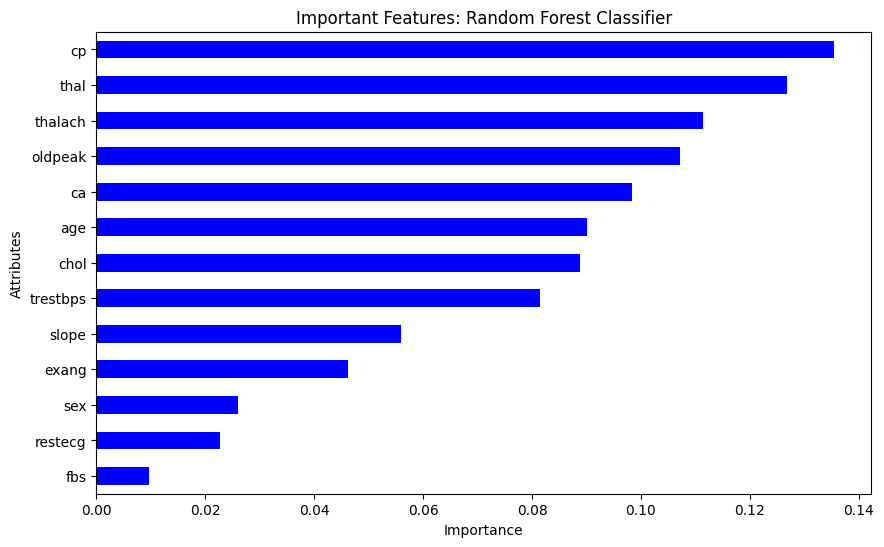

In [ ]:
import matplotlib.pyplot as plt

# getting the important features
important_features = rf_clf.feature_importances_
feature_names = X.columns

# making a series for easy plotting
rf_series= pd.Series(important_features,index=feature_names).sort_values(ascending=True)

# Plot
plt.figure(figsize=(10,6))
rf_series.plot(kind='barh', color = 'blue')
plt.title("Important Features: Random Forest Classifier")
plt.xlabel("Importance")
plt.ylabel("Attributes")
plt.show()

#### Top 7 important features that strongly contributes to predictions of heart disease
The graph above describes the feature importance levels for the random forest classifier. The x axis has the importance level from 0 to 0.14 and the y axis has the attributes that strongly contribute to the prediction outcomes of heart disease. At a feature importance level of 0.05, we can see that cp or Cheast Pain, thal or thalassemia which is some kind of blockage of blood flow to the heart, thalach or Maximum heart rate achieved, oldpeak or Exercise induced ST-depression in relative with the state of rest and ca or number of major vessels (0-3) colored by flourosopy and age. These 7 attributes contributed strongly in the prediction of heart disease. This matches to what we would expect when someone is diagnosed with heart disease, people often complain about chest pain when they are experiencing a heart attack and during prognosis it is often found that the person may have a blockage in the heart, other indications when a person goes in for a heart check up, they often do a treadmil test where the max heart rate is achieved or an angiogram is required to confirm or deny any heart vessel blockages. And finally the age of the person is also an important attribute that is often linked to heart disease. Generally people with higher levels of cholesterol tend to develop blocking of the arteries which could cause heart disease futher in life.


####8. Comment on your results in detail. Investigate the following ideas:


####8.(a). How do the models compare to each other? Which model performs best? Is this what you expected?
- From the confusion matrices and performance metrics generated for each individual model, we can say that the ensemble learning models like Random Forest and AdaBoosting classifiers performed the best with F1 Scores of 0.8518 and 0.8421. This gives us clear evidence that ensemble learning significantly improved the models against using a single decision tree which had an F1 score of 0.7857. The voting classifier only offered a slight improvement with an F1 score of 0.7777 which suggested that soft voting did not effectively improve model performance.

- Using the ensemble method, improved the performance significantly. The random forest classifier had performed the best with the highest precision (0.8846) and F1 score (0.8518) and also had a low misclassification of FN and FP. AdaBoosting had the best recall (0.8571) and the lowest number of FN. Overall the random forest was the best, balanced performing model. And this was expected that ensemble learning would outperform a single decision tree.

####8.(b) Bagging and boosting reduce different sources of error. Which type of ensemble works better here, and why might that be?
- In the terms of medically applying the best model to predict heart disease, the AdaBoosting model (Boosting) will be the best as it had the highest recall score (0.8571). This means that it missed the fewest number of FN (4). Even though Random Forest (bagging) achieves the highest overall F1 score, AdaBoosting gains the edge here because it had the lowest FN cases. Bagging reduces the variance by averaging multiple decision trees to get a more stable and balanced predictions. Boosting reduces bias and it is suited to capture the harder patterns in the data.
- For this case, correctly identifying heart disease is more challenging, so reducing the bias and using the AdaBoosting model will be better at detecting the disease.

####8.(c). What are the advantages and disadvantages of using an ensemble method over the decision tree baseline?
#### Advantages
  - Ensemble learning has higher predictive accuracy than the decision tree baseline by combining multiple models.
  - It reducing the tendancy to overfitting by aggregating predictions of multiple models predictions
  - They are more robust and stable at making predictions as compared to a decision tree baseline by averaging out predictions.
  - Ensemble learning techniques like bagging reduces variance while boosting reduces bias leading to better overall performance.
  - It is robust to noise in the data or outliers.
#### Disadvantages
  - Ensemble learning is more computationally expensive and slower to train
  - The combination of multiple models makes it difficult to interpret than a single decision tree
  - Boosting can act like a black box, making it difficult to understand the inner workings of the combined model.
  - Computational overhead for training and maintaining multiple models may be a disadvantage when resources are limited.

#### Part 2– Clustering of Faces





In [ ]:
from sklearn.datasets import fetch_olivetti_faces
data, targets = fetch_olivetti_faces(return_X_y=True)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


###1. Load the Olivetti Faces dataset using the code above. Briefly describe the dataset:
(a) How many examples are there? What does each example represent

In [ ]:
print(data.shape)
print(targets.shape)

(400, 4096)
(400,)


The data set contains 400 images that represent 40 distinct pictures of people where each person has 10 images each. This data was captured by AT&T Labs Cambridge between 1992 to 1994. Each example represents a 64 x 64 grayscale image of the persons face and its flattened into a vector 4096 pixel values and is labelled by the individual's identity. The "target" for this database is an integer from 0 to 39 indicating the identity of the person pictured, however, with only 10 examples per class, this relatively small dataset is more interesting from an unsupervised or semi-supervised perspective. The original dataset consisted of 92 x 112, while the version available here consists of 64x64 images.

(b) Describe the features. How many features are there, and what does each feature represent?

The features are 4096 in number. Each feature represents the intensity of a single pixel (0-255) in a 64 x 64 grayscale image which have been flattened into a one dimensional vector. But in this data set the pixel instensity has been scaled to 0 which is black and 1 which is white. This helps in capturing the visual structure of the face and textures. The images feature variations in lighting, facial expressions (open/closed eyes), and details (with/without glasses). All the features are scaled to be between 1 to 0 depending on the pixel shade. This dataset is usually used for dimensionality reduction which is the process to transform high dimensional data into a lower dimensional space to reduce noise and overcoming the curse of dimensionality.

2. Sample a random example from each class and display the images in a grid. Ensure each image is labelled with its class.

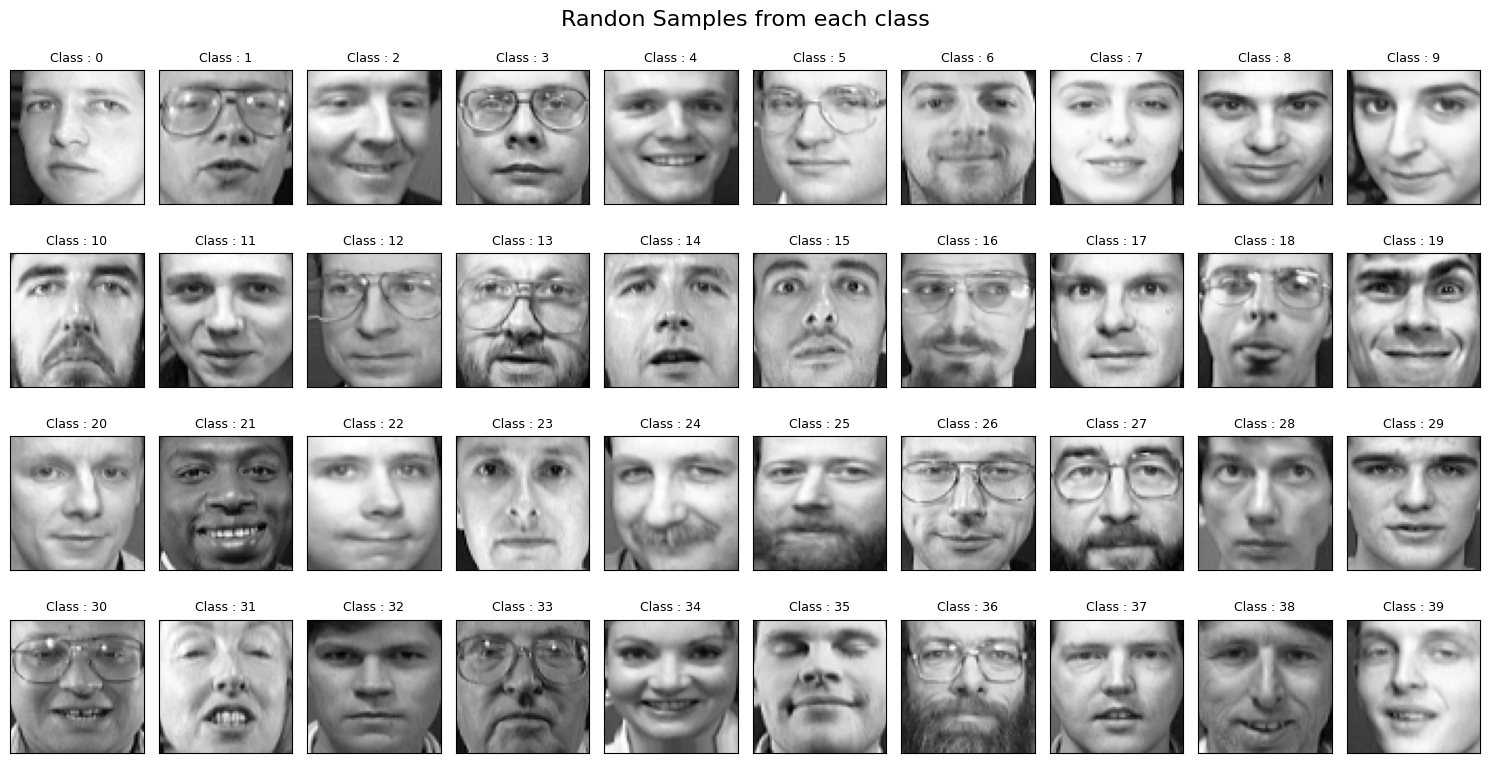

In [ ]:

# Setting up the figure as a grid
fig, axes = plt.subplots(4, 10, figsize=(15, 8),
                         subplot_kw={'xticks':[], 'yticks':[]})

# Going through each of the 40 classes

for i, ax in enumerate(axes.flat):
  indices_for_class = np.where(targets == i)[0]

  # Making a random choice

  random_index = np.random.choice(indices_for_class)

# Reshaping the image to make it visible
  image=data[random_index].reshape(64,64)

  # making sure that it is a greyscale image
  ax.imshow(image,cmap='grey')
  ax.set_title(f"Class : {i}", fontsize=9)

plt.suptitle("Randon Samples from each class", fontsize=16)
plt.tight_layout()
plt.show()


We can see from the sample that we have taken above, that images have various variations in the lighting, facial expressions i.e. open/closed eyes and details i.e. with/without glasses. We use a for loop to enumerate the target indices and then using numpy's random choice functions and then display the images.

#### What is Principal Component Analysis (PCA)?

Principal Component Analysis(PCA) is a dimensionality reduction technique in machine learning. It helps to reduce the number of features in a dataset while keeping the most important features or components. It changes a complex dataset by transforming correlated features into a smaller set of uncorrelated components. It uses linear algebra to transform the data into principal components. It calulates the eigenvectors(directions) and eigenvalues(importance) from a covariance matrix. it selects the top components with the highest eigenvalues and projects the data and projects onto a simplified dataset.

####3. Fit Principal Component Analysis (PCA) on the full dataset using scikit-learn.

(a) Plot the cumulative explained variance ratio against the number of components. Choose a
number of components that retains at least 95% of the variance and report this number.

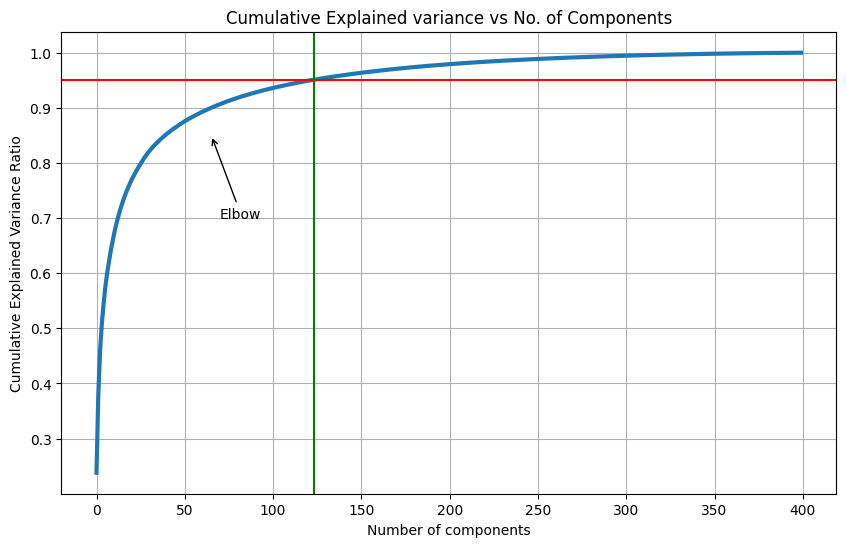


Number of components that explain 95% of the variance: 123


In [ ]:
from sklearn.decomposition import PCA

# Fitting PCA on full data set
pca_full = PCA(random_state=42)
pca_full.fit(data)

# Calculating the cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Finding the components that retains at least 95 % of the variance
n_components = np.argmax(cumulative_variance >= 0.95) + 1

# Plot
plt.figure(figsize=(10,6))
plt.plot(cumulative_variance, linewidth=3)
plt.axhline(y=0.95 , color= 'red', linestyle = "-")
plt.axvline(x= n_components, color= "green" , linestyle = "-")
plt.title("Cumulative Explained variance vs No. of Components")
plt.xlabel("Number of components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.annotate("Elbow", xy=(65, 0.85), xytext=(70, 0.7), arrowprops=dict(arrowstyle="->"))
plt.grid(True)
plt.show()

print("\nNumber of components that explain 95% of the variance:",n_components)

- From the plot above that shows the cumulative explained variance vs the number of components and we have the number of components on the x axis and the cumulative explained variance ratio on the y axis. We can see from the blue line that there is a sharp increase in the explained variance where the first few components have managed to capture big amounts of the dataset's structure. And as the blue line moves further to the right, it starts to taper out indicating that each additional component adds less and less new information.
- The red horizontal line represents that 95% threshold that we have defined to reduced the size of the data without loosing the important features. The green vertical line indicates the number of components that required to reach the 95% threshold, which is 123 components. This graph proves that you can represent the faces using only 123 numbers instead of 4096 while still keeping 95% of the original visual information. The elbow annotation is a visual representative of point of diminishing returns which is around the 60 - 70 number of components.


(b) Display the first 10 principal components as 64 × 64 images. These are known as eigenfaces.
Explain what these components represent and how they relate to the original images.

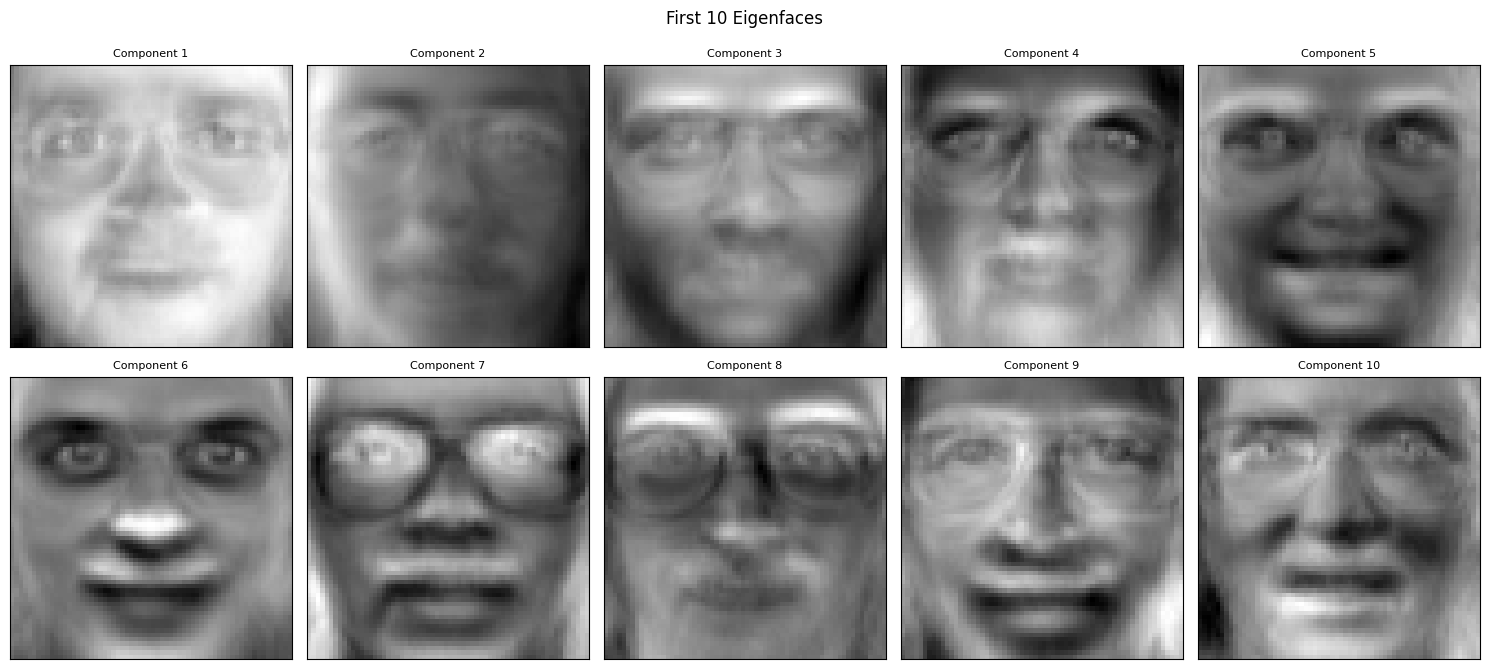

In [ ]:
# extracting the first 10 components from the pca
eigenfaces = pca_full.components_[:10]

# Setting up out plots for each component
fig, axis = plt.subplots(2,5, figsize=(15,7),subplot_kw={'xticks':[], 'yticks':[]})

# populating the subplots and reshaping them
for i, ax in enumerate(axis.flat):
  eigenfaces_image= eigenfaces[i].reshape(64,64)

  ax.imshow(eigenfaces_image,cmap='grey')
  ax.set_title(f"Component {i+1}", fontsize=8)

plt.suptitle("First 10 Eigenfaces",fontsize = 12)
plt.tight_layout()
plt.show()

These 10 components shown above are eigenfaces, these represent the most important patterns of variation in the face images. Each eigenface is a weighted combination of pixel intensity that captures specific features such as lighting, facial structure. These components are derived using the PCA algorithm that identifies directions in the data that explain the greatest variance. Where the first principal component captures the largest variation across all images and subsiquent components capture smaller variations.

The eigenfaces are approximately the linear combination of the original images. The PCA captures the reconstructed smaller set of principal components and their corresponding weights instead of all 4096 pixel values. This reduces dimensionality, while preserving the most important visual information in the data set.

(c) Project the data onto the first two principal components and produce a scatter plot, colouring
each point by its class. Comment on whether 2 components are sufficient to separate the
classes.

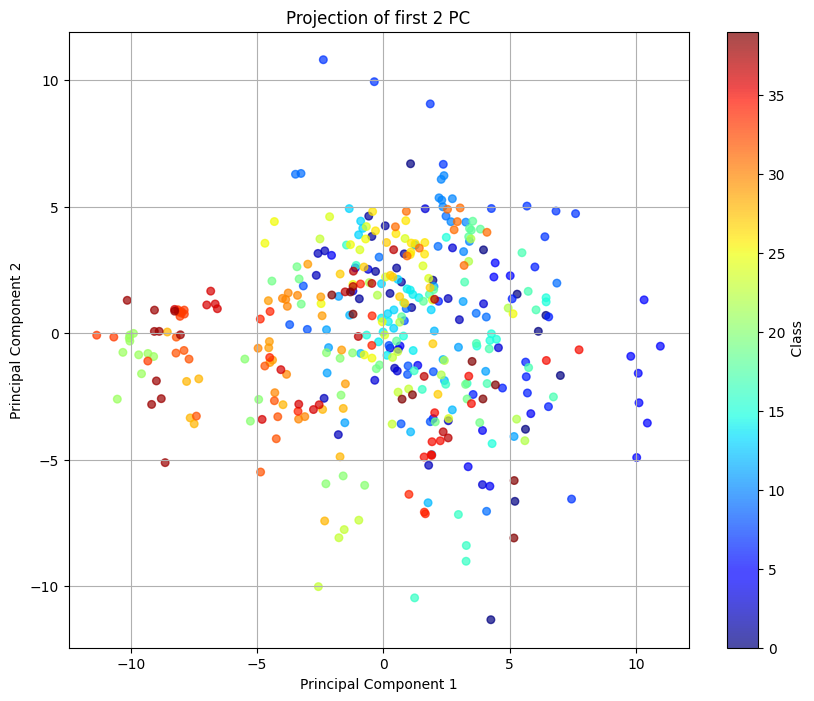

In [ ]:
# fitting the first 2 components
pca_2n = PCA(n_components=2, random_state=42)
pca_2n_fit=pca_2n.fit_transform(data)

# Scatter plot
plt.figure(figsize=(10,8))
scatter= plt.scatter(pca_2n_fit[:,0], pca_2n_fit[:,1], c = targets , cmap="jet",alpha=0.7, s= 30)
plt.colorbar(scatter,label = " Class")
plt.title("Projection of first 2 PC")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

The x axis is the principal component 1 (PC1) and y axis has the principal componet 2 (PC2) and each point represents one image. PC1 captures the highest variation and PC2 captures the second highest variation.

From the above scatter plot we see that the points that belong to different class are mixed up together. There is a high concentration of these points in the center of the plot. There are no clear clusters for any class. The projection onto the first 2 components tells us that the PCA has captured the main variation in the data but it cannot clearly seperate the individuals.The points are widly dispersed and with significant overlaps in the classes which gives us an indication that the 2 components are insufficient to distinguish the faces.




#### What is K-means clustering?

- K-means clustering is an algorithm that tries to group similar data points into clusters without needing labeled data. It is a form of unsupervised learning in machine learning by trying to uncover hidden patterns when the goal is to organise the data based on similarity. It works by identifying natural groupings in an unlabeled dataset, it groups points based on the distance to cluster centers. Its very useful when we need to structure raw, unorganised data.

#### 4. Apply k-Means clustering to the original feature space. Use k equal to the number of classes.
(a) Report the silhouette score of the clustering.

In [ ]:
# Applying k means with K = 40
from sklearn.cluster import KMeans

image_kmeans = KMeans(n_clusters= 40 , random_state = 42, n_init = 40)

# Fitting the model to the data
image_kmeans.fit(data)
# Silhouette score
from sklearn.metrics import silhouette_score

silhouette_kmeans_score= silhouette_score(data, image_kmeans.labels_)
print(f"Sihouette score for 40 clusters : {silhouette_kmeans_score:.4f}")




Sihouette score for 40 clusters : 0.1562


When we apply the k-means alogrithm to the images we define the hyperparameters i.e. number of clusters(k), in this case we defined 40 clusters to represent the 40 sets of unique targets. n_init is equal to 40, which is the number of times the k-means algorithm is run with different centroid seeds. The final results is the best output of n_init consecutive runs in terms of inertia.

The k means model achieved a silhouette score of 0.1562. The silhouette coefficient is a measure of how well each of the data points fits within its assigned cluster compared to other clusters. The values range from -1 to +1. A score closer to +1 suggests well seperated clusters and near 0 means overlapping clusters.

A value of 0.1562 is low, this is suggesting that there is a weak cluster structure. The data points lie close to the cluster boundaries and that the clusters formed by k means are not well seperated.

(b) Visualise the cluster centroids as 64 × 64 images. Compare them to the eigenfaces from the
previous task.

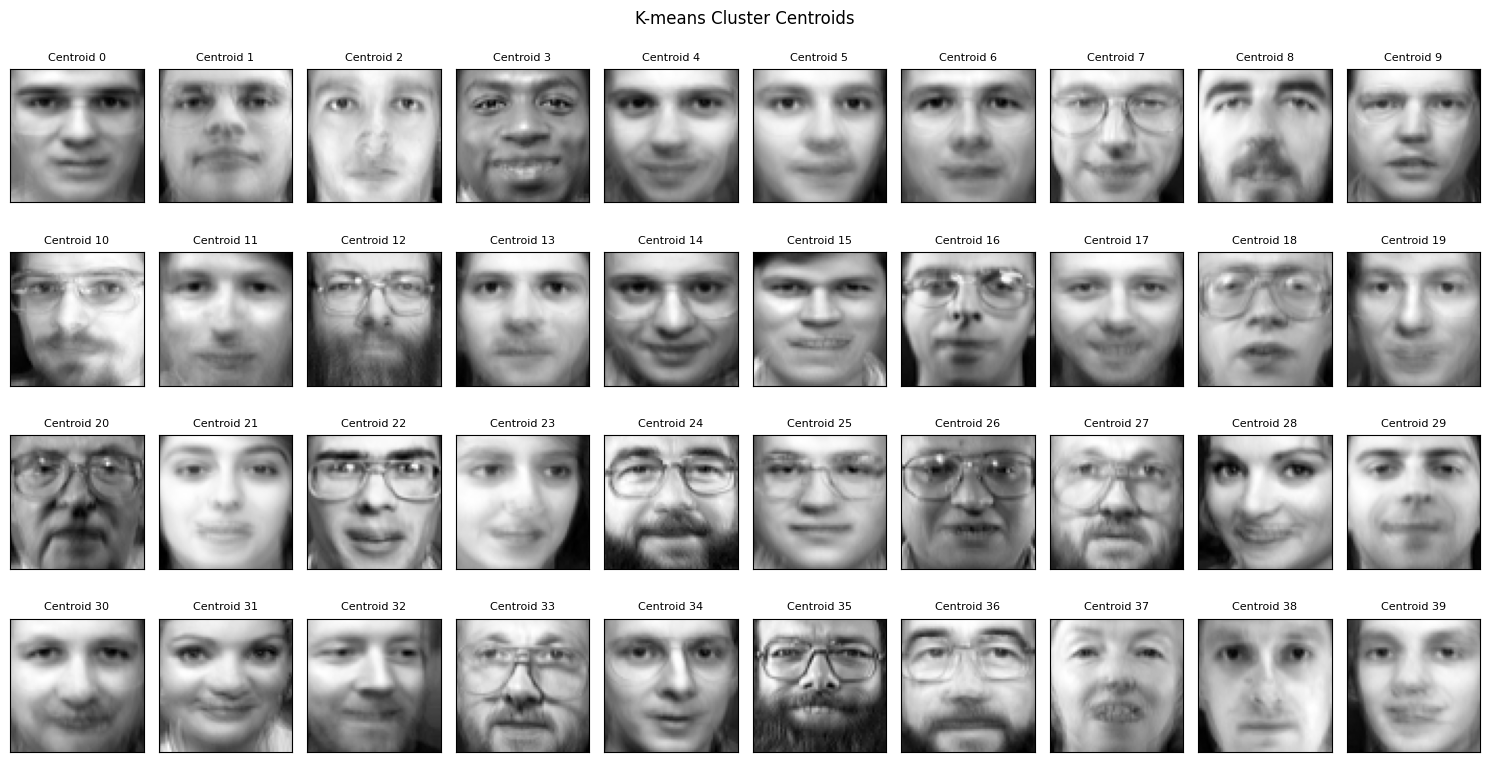

In [ ]:
# Extracting the 40 cluster centroids
full_centroids = image_kmeans.cluster_centers_

# Setting up out plots for each component
fig, axis = plt.subplots(4,10, figsize=(15,8),subplot_kw={'xticks':[], 'yticks':[]})

# populating the subplots and reshaping them
for i, ax in enumerate(axis.flat):
  full_centroids_image= full_centroids[i].reshape(64,64)

  ax.imshow(full_centroids_image,cmap='grey')
  ax.set_title(f"Centroid {i}", fontsize=8)

plt.suptitle("K-means Cluster Centroids",fontsize = 12)
plt.tight_layout()
plt.show()


Comparing the k-means output to the eigenfaces we can see that they capture different aspects of the data. The centeroids in the k-means model are average faces for each cluster, so they appear as blurry images and show common features such as lighting and face shape. But they lack sharp detail and some images look similar to each other which indicates a weak cluster seperation. For example, we can see blurry images for centroid 19, 39.

The eigenfaces are the directions of maximum variance and they represent the key patterns in the data such as lighting, shadows and the structural facial differences. They form the basis for reconstructing the images and capture the most variations in the data set. That is why they do not look like actual faces and gives them a ghostly look to the images.

The eigenfaces are the best at providing meaningful representation of the data. PCA preserves the global structure while k-means relies on the similarity in high dimensional space which is less effective in this data set.

#### 5. Repeat the k-Means clustering, this time on the PCA-reduced data.
(a) Report the silhouette score for the PCA-reduced clustering.

In [ ]:
# Fitting a reduced PCA model with at least 95% of the explained variance
pca_reduced = PCA(n_components=n_components , random_state = 42)
pca_reduced_fit = pca_reduced.fit_transform(data)

# Fitting k means on reduced data
kmeans_reduced_pca = KMeans(n_clusters=40, random_state = 42, n_init = 100)
kmeans_reduced_pca_fit = kmeans_reduced_pca.fit(pca_reduced_fit)

silhouette_score_pca = silhouette_score(pca_reduced_fit, kmeans_reduced_pca.labels_)

print(f"Silhouette score on reduced PCA: {silhouette_score_pca:.4f}")

Silhouette score on reduced PCA: 0.1810


- Here we are fitting a PCA model with the number of components hyperparameter with n_components which is 123 that keeps 95% of the variance and helps reduce the feature space. We fit a k means with the PCA reduced data and increased the n_init to 100, where K means runs 100 different random initialisations. Higher n_init usually gives more stable results. It follows a series of steps where it randomly initialises centroids and assigns observations to the neareast centroid and updates it each time till it converges.

- We evaluate the clustering quality using the Silhouette coefficient to measure the distance of points within their own cluster and compares them to other clusters and we can see that the silhouette score was sightly improved to 0.1810 from 0.1562.



(b) Plot the silhouette diagrams for both the original and PCA-reduced clusterings, and compare
them.

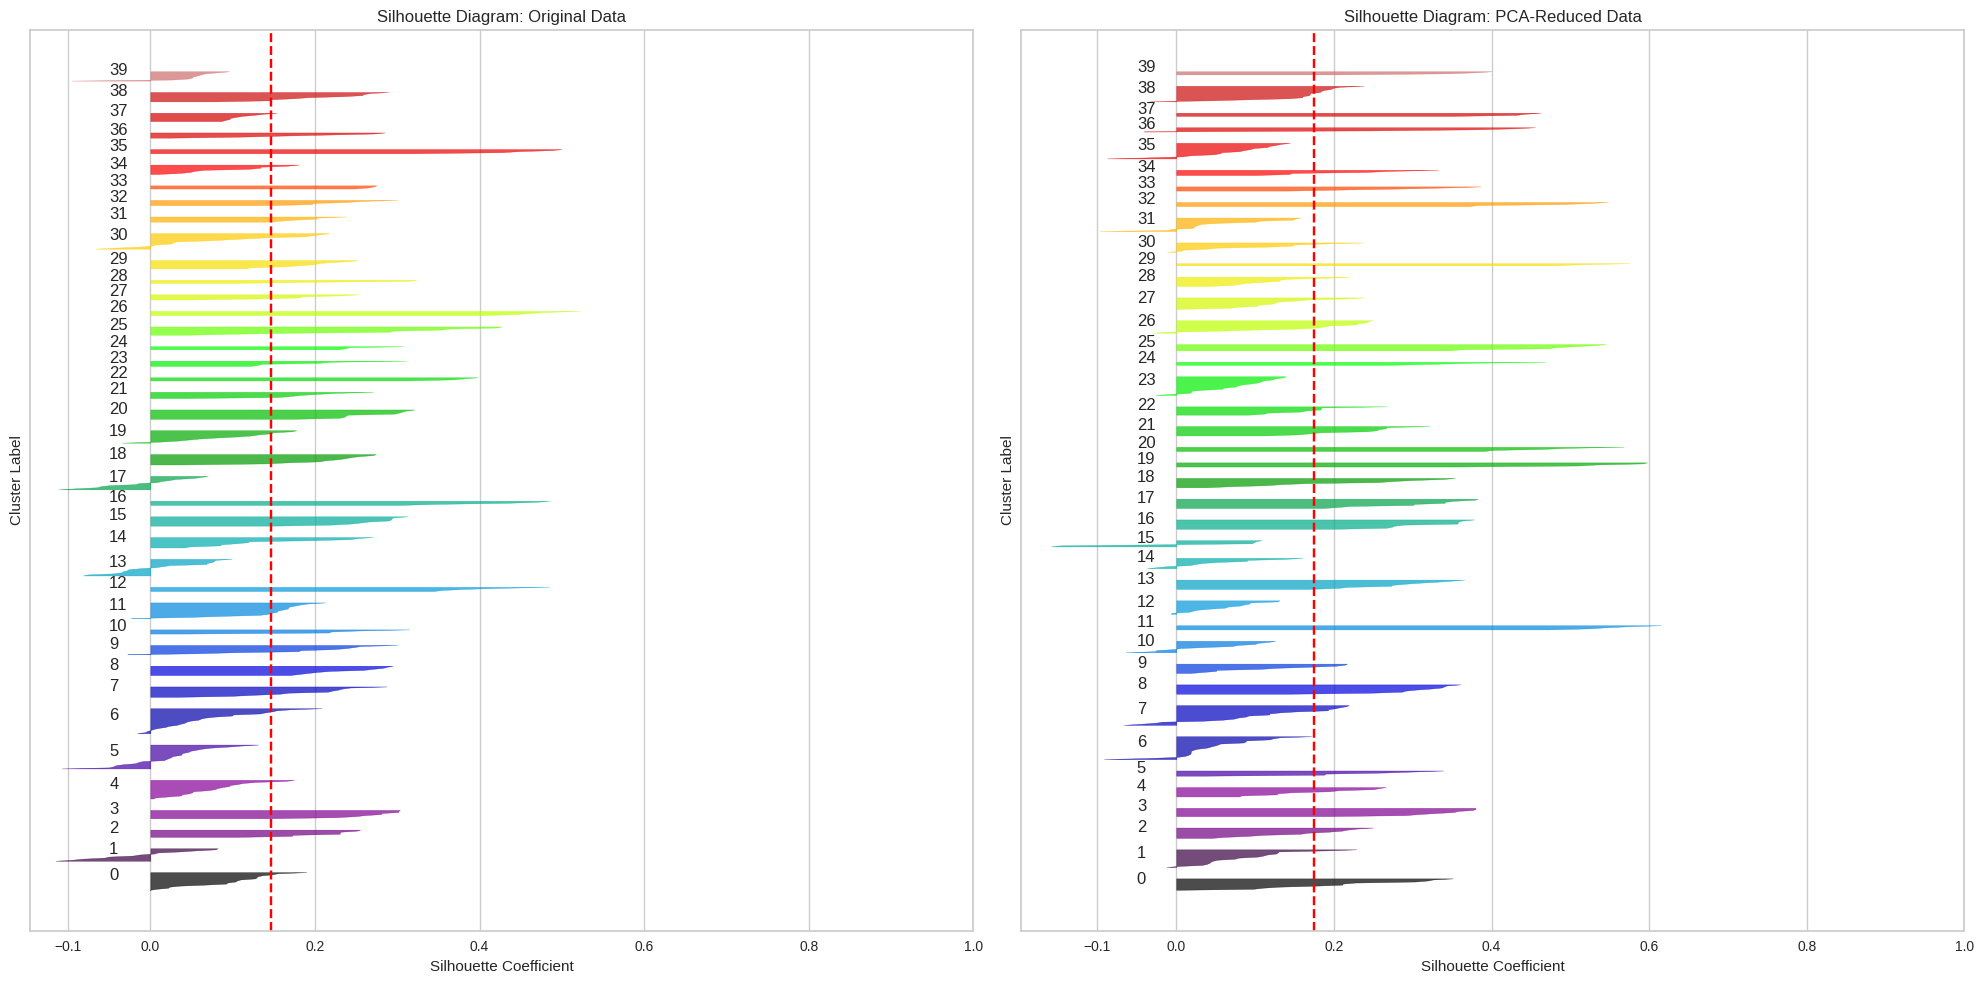

In [ ]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples

def plot_silhouette(X, labels, title, ax):
    n_clusters = len(np.unique(labels))
    silhouette_avg = silhouette_score(X, labels)
    sample_silhouette_values = silhouette_samples(X, labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate and sort silhouette scores for samples in cluster
        silhouette_values = sample_silhouette_values[labels == i]
        silhouette_values.sort()

        cluster_size = silhouette_values.shape[0]
        y_upper = y_lower + cluster_size

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with cluster numbers at the middle
        ax.text(-0.05, y_lower + 0.5 * cluster_size, str(i))
        y_lower = y_upper + 10

    ax.set_title(title)
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Cluster Label")
    ax.axvline(x=silhouette_avg, color="red", linestyle="--") # Average score
    ax.set_yticks([])
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

# comparison the figures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
plot_silhouette(data, image_kmeans.labels_, "Silhouette Diagram: Original Data", ax1)
plot_silhouette(pca_reduced_fit, kmeans_reduced_pca_fit.labels_, "Silhouette Diagram: PCA-Reduced Data", ax2)  #### -------- add the silhouette score to the diagrams ----
plt.tight_layout()
plt.show()

From the Silhouette diagram above the x axis represents the silhouette coefficient and the y axis represents the cluster labels. The red dotted line represents the average silhouette score for each model.

We can see a noticed increase in the average silhouette score from the orginal model which was 0.1562 to 0.1810. This indicates that the clusters became slightly more seperated than the orginal data set.

There is uneven cluster quality where clusters with higher averages (0.4~0.6) were better grouped and the lower averages near 0 or negative were poorly grouped. In the orginal dataset we had several clusters which significant tails in the negative region which meant that those specific images were closer to a neighboring cluster.

We can also see that the silhouette diagram has something that resembles a knife blade. We can see that there is some uniformatity to the blades. If a knife blade is wider and flatter like in clusters 26 and 35, this indicates that the clusters have very distinct features and K-means was able to group them easily. Contrast to these, cluster 39 has a much thinner and shorter blade, which indicates that the image significantly vary in the lighting or pose, which makes it hader for the algorithm to classify correctly.

####6. Comment on your results in detail. Investigate the following ideas:
(a) How does PCA affect the quality of the k-Means clustering? Discuss the performance.

When we combined PCA to the K-means clustering, when comparing it to the orginal dataset. The k-means clustering performed poorly as we could see from the silhouette score (0.1562) and there was significant overlap between the classes. We also saw blurry images when we plotted the class label, during the replication of the data. The data contained noise and redundant features, which made it difficult for k-means clustering to make well seperated clusters. The Silhouette diagram also show many clusters that had negative values which indicated that some data points were closer to a cluster boundry.

When we applied the PCA before using k-means we saw an improvement as the PCA captured the most important variances in the data. This reduced the noise and redundancy in the data by projecting the data onto a lower dimensional space which lead to a slight increase in the quality of cluster structures and also by increasing the n_init hyperparameter to 100, We saw that this lead to the Silhouette score increase to (0.1810) and the Silhouette diagram showed fewer data points closer to a cluster boundary and k-means clustering became less confused by irrelevant pixel variations in the reduced dimension space.

But, the overall performance remained limited. The clusters were still not well seperated and the overlap between classes remained. But using the PCA as a pre processing step, enhanced the k-means clustering performance by concentrating the variance into meaninful components and made the k-means model produce more stable clusters by reducing the noise and redundant features.

(b) What are the advantages and disadvantages of using PCA before clustering, compared with
clustering on the raw features?


#### Advantages of PCA before clustering <n>
1. PCA creates new and uncorrelated variables to address the issues when orginal features are highly correlated, thereby addressing the issue of Multicollinearity.
2. It helps to reduce the noise within the data and eliminates the components with low variance to enhance data clarity.
3. PCA reduces the storage need and speeds up the process by keeping the components that have the highest variance.
4. It helps in identifying outliers by showing unusual data points that deviate significantly in the reduced space.
5. It helps to mitigate the curse of dimensionality, it reduces the numerous and sparse features that aid it in identifying more significant clusters.

#### Disadvantages of PCA before clustering <n>
1. It becomes harder to interpret the new components because they are combinations of the original variables.
2. It is sensitive to data scaling as it requires proper scaling of the data before implementation, otherwise the results can be misleading.
3. When PCA is undertaken there is information that is lost when reducing the dimensions and we lose some important information if too few components are kept.
4. PCA assusmes that the data is linear and it works best if the relationship between variables are linear but might struggle with non linear relationships.
5. If the datasets that we deal with are very large, it can be very slow and resourse intensive.